In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'<<{_str}>>:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

# Model 설계 workfolw

In [2]:
!pip -q install lightning torchinfo  # Wall time: 1min 32s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 59.3 MB/s eta 0:00:00


In [3]:
import torch
from torch import nn, torch_version
from torch.nn import functional as F
import torch.optim as optim

import lightning as L
from lightning.pytorch.accelerators import accelerator
import torchmetrics
from torchmetrics import functional as FM
from torchinfo import summary

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import torch.utils.data as data
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

torch.__version__,L.__version__,torchmetrics.__version__,torch_version.__version__

('2.8.0+cu126', '2.5.5', '1.8.2', '2.8.0+cu126')

## 1. 첫번째 모델 만들기

###  Model 정의

In [4]:
class FirstModel(L.LightningModule):
    def __init__(self):
        super(FirstModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 10) )

    def forward(self, x):
        out = self.layers(x)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        self.log_dict({'loss':loss, 'acc':acc})#,on_step=True, on_epoch=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        self.log_dict({'val_loss':loss, 'val_acc':acc})#,on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

* Model 생성, Summary보기

Tensorflow's  `model.summary()` API like view :  https://github.com/TylerYep/torchinfo

In [5]:
from torchinfo import summary

model = FirstModel()
print( summary(model) )  # Layer별 출력 shape을 볼수 없음

print('++++++')
print( summary(model, (1, 1, 28, 28)) )

print('++++++')
print( summary(model, (128, 1, 28, 28)) )

Layer (type:depth-idx)                   Param #
FirstModel                               --
├─Sequential: 1-1                        --
│    └─Flatten: 2-1                      --
│    └─Linear: 2-2                       7,850
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
++++++
Layer (type:depth-idx)                   Output Shape              Param #
FirstModel                               [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 784]                  --
│    └─Linear: 2-2                       [1, 10]                   7,850
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.03
++++++
Layer (type:depth-idx)                   Output Shape              Param #
FirstModel                        

In [6]:
print(f"Total params: {(784*10+10)}")  #((input*nodes+nodes)
print(f"Params size(M/B): {(784*10+10)*4/1024/1024:.2f}")  #((input*nodes+nodes)*W/Byte)

Total params: 7850
Params size(M/B): 0.03


Forward/Backward Pass Size :   
순전파(Forward) 동안 각 레이어의 활성화 값 저장에 필요한 메모리.  
  +역전파(Backward) 동안 활성화 값의 그라디언트 저장에 필요한 메모리.

In [7]:
print(f"Input size:  {784*128*4/1024/1024:.2f}")                    #(input*bs*W/B)
print(f"Forward/bacward pass size: {(784+10)*4*2/1024/1024:0.2f}")  #(layer1_out+layer2_out)*W/B*2(f/b)
print(f"Parmas size:  {7850*4/1024/1024:.2f}")                      #(Total_params*W/B)

Input size:  0.38
Forward/bacward pass size: 0.01
Parmas size:  0.03


### Dataset 준비

In [8]:
!lscpu  # CPU(s): 8

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      8
  On-line CPU(s) list:       0-7
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      4
    Socket(s):               1
    Stepping:                3
    BogoMIPS:                4000.45
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

#### num_workers  
##### MNIST는 memory에 모두 load되므로 file i/o 병목이 없음
##### 그럼에도 0,1 보다 4를 쓰면 속도 향상 있음(기본적인 전처리:ToTensor()등이 병렬처리 됨)       

In [9]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def dataLoader(batch_size=128):
    train_dataset = MNIST('', transform=transforms.ToTensor(), train=True, download=True)
    test_dataset = MNIST('', transform=transforms.ToTensor(), train=False, download=True)
    trainDataLoader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    valDataLoader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    return trainDataLoader,valDataLoader

trainDataLoader,valDataLoader = dataLoader()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 125kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


### Training, History logging

In [11]:
%%time
model = FirstModel()
epochs = 5
logger = L.pytorch.loggers.CSVLogger("logs", name="firstModel")
trainer = L.Trainer(max_epochs=epochs, logger=logger) #default: accelerator="auto"
trainer.fit(model, trainDataLoader, valDataLoader)
# Wall time: 17.9 s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


CPU times: user 12.7 s, sys: 1.91 s, total: 14.6 s
Wall time: 16.2 s


### torch.compile() API : 일반적으로 5%에서 30% 정도의 속도 향상을 기대   
#### model 크기, GPU 종류에 따라 다름(최신 GPU에서 효과적)  
#### input shape이 변할때 마다 다시 compile하므로, shape이 고정되어 있어야 효과적    
#### 현재 코드에서는 : Lightning logger호출시 shape이 달라져서 재컴파일이 발생하여 더 늦어지고 있음

In [ ]:
%%time
model = FirstModel()
model = torch.compile(model) #######
epochs = 5
logger = L.pytorch.loggers.CSVLogger("logs", name="firstModel")
trainer = L.Trainer(max_epochs=epochs, logger=logger) #default: accelerator="auto"
trainer.fit(model, trainDataLoader, valDataLoader)
# Wall time: 40.7 s

* Log data 보기

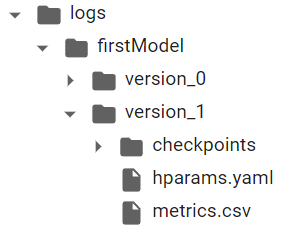

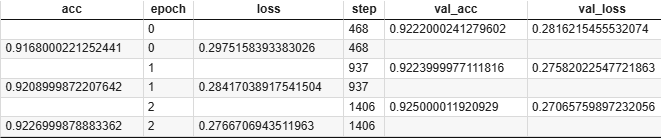

### Test

In [ ]:
test_batch = next(iter(valDataLoader))            #(128,1,28,28),(128,) <-
preds = model(test_batch[0])                      #image만  #(128,10) <- (128,1,28,28)
p(preds[0],'preds'),print()                       # Class logits (10,)
p(torch.softmax(preds[0],dim=0),'softmax'),print()# Class Prob.  (10,)
p(np.argmax(torch.softmax(preds[0],dim=0).detach()),'index') # Class idx
p(np.argmax(preds[0].detach()),'index')           #  확률로 바꿀필요 없음

* History file read

In [12]:
v_num = logger.version
history = pd.read_csv(f'./logs/firstModel/version_{v_num}/metrics.csv')
#history
history.groupby('epoch').last().drop('step', axis=1)

,acc,loss,val_acc,val_loss
epoch,,,,
0,0.859375,0.447517,0.9036,0.377431
1,0.921875,0.298297,0.9127,0.319399
2,0.882812,0.372880,0.9187,0.296010
3,0.914062,0.274660,0.9211,0.284790
4,0.976562,0.148286,0.9218,0.280358


**training_step()**   
>**self.log_dict({'loss':loss, 'acc':acc})#,on_step=True,on_epoch=False**   

**validation_step()**   
>**self.log_dict({'val_loss':loss, 'val_acc':acc})#  on_step=False, on_epoch=True**  
---
**history**

|loss|step|epoch|acc|acc_loss|val_acc|   
|---|---|---|---|---|---|  
|1.146201|	49|	0|	0.820312|	NaN|	NaN|  
|0.755413|	99|	0|	0.875000|	NaN|	NaN|
|0.609857|	149|	0|	0.914062|	NaN|	NaN|
|0.463113|	199|	0|	0.898438|	NaN|	NaN|
|0.595312|	249|	0|	0.875000|	NaN|	NaN|
|0.507147|	299|	0|	0.851562|	NaN|	NaN|
|0.407075|	349|	0|	0.921875|	NaN|	NaN|
|0.569688|	399|	0|	0.882812|	NaN|	NaN|
|0.434655|	449|	0|	0.875000|	NaN|	NaN|
|NaN|	468|	0|	NaN|	0.380818|	0.9009|
|0.448470|	499|	1|	0.867188|	NaN|	NaN|


**history.groupby('epoch').last().drop('step', axis=1)**  

|epoch|loss|acc|val_loss|	val_acc|  
|---|---|---|---|---|  
|0|	0.434655|	0.875000|	0.380818|	0.9009|
|1|	0.250425|	0.953125|	0.318103|	0.9141|
|2|	0.368772|	0.890625|	0.297457|	0.9170|


**training_step()**   
>**self.log_dict({'loss':loss, 'acc':acc},on_step=False,on_epoch=True)**   

**validation_step()**   
>**self.log_dict({'val_loss':loss, 'val_acc':acc})#  on_step=False, on_epoch=True**  
---
**history**  

|epoch|val_loss|val_acc|step|loss|acc|   
|---|---|---|---|---|---|  
|0|	0.381324|	0.9026|	468|	NaN|	NaN|  
|0|	NaN|	NaN|	468|	0.659255|	0.848500|  
|1|	0.316955|	0.9136|	937|	NaN|	NaN|  
|1|	NaN|	NaN|	937|	0.358495|	0.904467|  
|2|	0.296339|	0.9170|	1406|	NaN|	NaN|  
|2|	NaN|	NaN|	1406|	0.316879|	0.912967|  

**history.groupby('epoch').last().drop('step', axis=1)**  

|epoch|loss|acc|val_loss|	val_acc|  
|---|---|---|---|---|  
|0|	0.434655|	0.875000|	0.380818|	0.9009|
|1|	0.250425|	0.953125|	0.318103|	0.9141|
|2|	0.368772|	0.890625|	0.297457|	0.9170|


## 2. 모듈을 만드는 방법

### 1 Module container 사용

In [31]:
class Model(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(5, 10)
        self.linear2 = nn.Linear(10,1)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        return x

model = Model()
summary(model, input_size=(8, 5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 1]                    --
├─Linear: 1-1                            [8, 10]                   60
├─Linear: 1-2                            [8, 1]                    11
Total params: 71
Trainable params: 71
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [32]:
model

Model(
  (linear1): Linear(in_features=5, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=1, bias=True)
)

**module class를 instance하여 module 구성하기**

In [33]:
class MyModel(L.LightningModule):
    def __init__(self):
        super(MyModel, self).__init__()
        self.layers =  Model()

    def forward(self, x):
        out = self.layers(x)
        return out

model = MyModel()
summary(model, input_size=(8, 5))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [8, 1]                    --
├─Model: 1-1                             [8, 1]                    --
│    └─Linear: 2-1                       [8, 10]                   60
│    └─Linear: 2-2                       [8, 1]                    11
Total params: 71
Trainable params: 71
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [34]:
p(model,'model');print()
p(model.layers,'model.layers');print()
p(model.layers.linear1,'model.layers.linear1');print()
p(model.layers.children,'model.layers.children')

<<model>>:
Type: <class '__main__.MyModel'>
Values: MyModel(
  (layers): Model(
    (linear1): Linear(in_features=5, out_features=10, bias=True)
    (linear2): Linear(in_features=10, out_features=1, bias=True)
  )
)

<<model.layers>>:
Type: <class '__main__.Model'>
Values: Model(
  (linear1): Linear(in_features=5, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=1, bias=True)
)

<<model.layers.linear1>>:
Type: <class 'torch.nn.modules.linear.Linear'>
Values: Linear(in_features=5, out_features=10, bias=True)

<<model.layers.children>>:
Type: <class 'method'>
Values: <bound method Module.children of Model(
  (linear1): Linear(in_features=5, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=1, bias=True)
)>


### 2.1 Sequential container : Type 1

 - argument로 module을 전달



In [17]:
class Model(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.layers =  nn.Sequential(
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64,10),
            # F.softmax(dim=1)   ## error !!
            nn.Softmax(),
            )
    def forward(self, x):
        out = self.layers(x)
        # out = F.softmax(out, dim=1) ## ok!!
        return out

model = Model()
summary(model, input_size=(8, 1, 28*28))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1879: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return inner()


Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 1, 10]                --
├─Sequential: 1-1                        [8, 1, 10]                --
│    └─Linear: 2-1                       [8, 1, 64]                50,240
│    └─ReLU: 2-2                         [8, 1, 64]                --
│    └─Linear: 2-3                       [8, 1, 10]                650
│    └─Softmax: 2-4                      [8, 1, 10]                --
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.03
Forward/backward pass size (MB): 0.00
Params size (MB): 0.20
Estimated Total Size (MB): 0.23

In [18]:
model

Model(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
    (3): Softmax(dim=None)
  )
)

### 2.2 Sequential + add_module(): Type 2

In [19]:
class Model(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.Sequential()
        self.layers.add_module('linear1', nn.Linear(28*28, 64))
        self.layers.add_module('linear2', nn.Linear(64,10))

    def forward(self, x):
        out = self.layers(x)
        return out

model = Model()
summary(model, input_size=(8, 1, 28*28))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 1, 10]                --
├─Sequential: 1-1                        [8, 1, 10]                --
│    └─Linear: 2-1                       [8, 1, 64]                50,240
│    └─Linear: 2-2                       [8, 1, 10]                650
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.03
Forward/backward pass size (MB): 0.00
Params size (MB): 0.20
Estimated Total Size (MB): 0.23

In [20]:
model

Model(
  (layers): Sequential(
    (linear1): Linear(in_features=784, out_features=64, bias=True)
    (linear2): Linear(in_features=64, out_features=10, bias=True)
  )
)

### 2.3 Sequential + OrderedDict : Type 3

In [21]:
from collections import OrderedDict
class Model(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.Sequential(OrderedDict([
            ('flatten', nn.Flatten()),
            ('linear1', nn.Linear(28*28,64)),
            ('linear2', nn.Linear(64,10)),
          ]))
    def forward(self, x):
        out = self.layers(x)
        return out

model = Model()
summary(model, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10]                   --
├─Sequential: 1-1                        [8, 10]                   --
│    └─Flatten: 2-1                      [8, 784]                  --
│    └─Linear: 2-2                       [8, 64]                   50,240
│    └─Linear: 2-3                       [8, 10]                   650
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.03
Forward/backward pass size (MB): 0.00
Params size (MB): 0.20
Estimated Total Size (MB): 0.23

In [22]:
model

Model(
  (layers): Sequential(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (linear1): Linear(in_features=784, out_features=64, bias=True)
    (linear2): Linear(in_features=64, out_features=10, bias=True)
  )
)

### 3 ModuleList

In [23]:
class Model(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(10, 10) for i in range(5)])

    def forward(self, x):
        for l in self.linears:
            x = l(x)
        return x

model = Model()
summary(model, input_size=(8, 1, 10))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 1, 10]                --
├─ModuleList: 1-1                        --                        --
│    └─Linear: 2-1                       [8, 1, 10]                110
│    └─Linear: 2-2                       [8, 1, 10]                110
│    └─Linear: 2-3                       [8, 1, 10]                110
│    └─Linear: 2-4                       [8, 1, 10]                110
│    └─Linear: 2-5                       [8, 1, 10]                110
Total params: 550
Trainable params: 550
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

In [24]:
model

Model(
  (linears): ModuleList(
    (0-4): 5 x Linear(in_features=10, out_features=10, bias=True)
  )
)

In [25]:
class Model(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(10, 10) for i in range(5)])

    def forward(self, x):
        # ModuleList can act as an iterable, or be indexed using ints
        for i, l in enumerate(self.linears):
            x = self.linears[i // 2](x) + l(x)
        return x
    #0: x = l[0](x)+l[0](x)
    #1: x = l[0](x)+l[1](x)
    #2: x = l[1](x)+l[2](x)
    #3: x = l[1](x)+l[3](x)
    #4: x = l[2](x)+l[4](x)

model = Model()
summary(model, input_size=(8, 1, 10))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 1, 10]                --
├─ModuleList: 1-1                        --                        --
│    └─Linear: 2-1                       [8, 1, 10]                110
│    └─Linear: 2-2                       [8, 1, 10]                (recursive)
│    └─Linear: 2-3                       [8, 1, 10]                (recursive)
│    └─Linear: 2-4                       [8, 1, 10]                110
│    └─Linear: 2-5                       [8, 1, 10]                (recursive)
│    └─Linear: 2-6                       [8, 1, 10]                110
│    └─Linear: 2-7                       [8, 1, 10]                (recursive)
│    └─Linear: 2-8                       [8, 1, 10]                110
│    └─Linear: 2-9                       [8, 1, 10]                (recursive)
│    └─Linear: 2-10                      [8, 1, 10]                110
Total params: 550
Trainable params:

In [26]:
model

Model(
  (linears): ModuleList(
    (0-4): 5 x Linear(in_features=10, out_features=10, bias=True)
  )
)

### 4 ModuleDict

In [35]:
class Model(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.choices = nn.ModuleDict({
                'conv': nn.Conv2d(10, 10, 3),
                'pool': nn.MaxPool2d(2)
        })
        self.activations = nn.ModuleDict([
                ['lrelu', nn.LeakyReLU()],
                ['prelu', nn.PReLU()]
        ])

    def forward(self, x, choice, act):
        x = self.choices[choice](x)
        x = self.activations[act](x)
        return x

model = Model()

In [36]:
## Total mult-adds : 4.92
summary(model, input_size=(8, 10, 28, 28),choice='conv',act='prelu')

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10, 26, 26]           --
├─ModuleDict: 1-1                        --                        --
│    └─Conv2d: 2-1                       [8, 10, 26, 26]           910
├─ModuleDict: 1-2                        --                        --
│    └─PReLU: 2-2                        [8, 10, 26, 26]           1
Total params: 911
Trainable params: 911
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.92
Input size (MB): 0.25
Forward/backward pass size (MB): 0.87
Params size (MB): 0.00
Estimated Total Size (MB): 1.12

In [29]:
## Total mult-adds : 0
summary(model, input_size=(8, 10, 28, 28),choice='pool',act='lrelu')

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10, 14, 14]           --
├─ModuleDict: 1-1                        --                        910
│    └─MaxPool2d: 2-1                    [8, 10, 14, 14]           --
├─ModuleDict: 1-2                        --                        1
│    └─LeakyReLU: 2-2                    [8, 10, 14, 14]           --
Total params: 911
Trainable params: 911
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 0.25
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.25

In [37]:
model

Model(
  (choices): ModuleDict(
    (conv): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (activations): ModuleDict(
    (lrelu): LeakyReLU(negative_slope=0.01)
    (prelu): PReLU(num_parameters=1)
  )
)

### Module class vs. Function class
#### module 내부에서는 mocule class를 사용해야 함

**nn.** Softmax            : module class  
**nn.functional.** softmax : function class

In [38]:
### nn.Softmax            : module class
### nn.functional.softmax : function class

input = torch.randn(2, 3)

# module class
output = nn.Softmax(dim=1)(input) # instance생성 후 입력값을 받음
p(output,'module')
print('++++++')

# functional class
output = F.softmax(input,dim=1)
p(output,'function')   # <class 'function'>

## 결과는 같지만 모델 구성에서는 차이가 있음

<<module>>:
Shape:torch.Size([2, 3])
Type: <class 'torch.Tensor'>
Values: tensor([[0.1133, 0.8498, 0.0369],
        [0.5336, 0.0595, 0.4069]])
++++++
<<function>>:
Shape:torch.Size([2, 3])
Type: <class 'torch.Tensor'>
Values: tensor([[0.1133, 0.8498, 0.0369],
        [0.5336, 0.0595, 0.4069]])


In [39]:
## nn.Softmax() : model.train() / model.eval()에서 상태 변경 가능

class Model_error(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.layers =  nn.Sequential(
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64,10),
            F.softmax(dim=1)   ## error !!
#            nn.Softmax(),
            )
    def forward(self, x):
        out = self.layers(x)
        out = F.softmax(out, dim=1) ## ok!!
        return out

model = Model_error()
#summary(model, input_size=(8, 1, 28*28))

TypeError: super(type, obj): obj must be an instance or subtype of type

### 모델 시각화

In [41]:
class Model(L.LightningModule):
    def __init__(self):
        super(Model, self).__init__()
        self.flatten =  nn.Flatten()
        self.linear1 = nn.Linear(28*28, 32)
        self.linear2 = nn.Linear(28*28, 32)
        self.linear3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x1 = self.linear1(x)
        x1 = self.relu(x1)
        x2 = self.linear2(x)
        x2 = self.relu(x2)
        x = torch.cat([x1, x2], dim=1)
        x = self.linear3(x)
        return x

model = Model()
summary(model, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [8, 10]                   --
├─Flatten: 1-1                           [8, 784]                  --
├─Linear: 1-2                            [8, 32]                   25,120
├─ReLU: 1-3                              [8, 32]                   --
├─Linear: 1-4                            [8, 32]                   25,120
├─ReLU: 1-5                              [8, 32]                   --
├─Linear: 1-6                            [8, 10]                   650
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.03
Forward/backward pass size (MB): 0.00
Params size (MB): 0.20
Estimated Total Size (MB): 0.23

In [42]:
model

Model(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=784, out_features=32, bias=True)
  (linear2): Linear(in_features=784, out_features=32, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

https://github.com/lutzroeder/netron

In [43]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 147.5 MB/s eta 0:00:00


In [44]:
device ='cuda:0'
torch.onnx.export(model, torch.zeros((8, 1, 28, 28)).to(device), 'model.onnx')

/tmp/ipython-input-2558406983.py:2: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(model, torch.zeros((8, 1, 28, 28)).to(device), 'model.onnx')


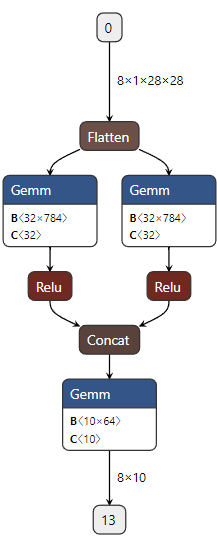

## Model = Module + methods

### training_step( )

### Training History logging
>Logging from a LightningModule :  
https://lightning.ai/docs/pytorch/stable/api_references.html#loggers

```python
LightningModule.log(name, value,
    prog_bar=False, logger=True, on_step=None, on_epoch=None, reduce_fx='mean',
    enable_graph=False, sync_dist=False, sync_dist_group=None, add_dataloader_idx=True,
    batch_size=None, metric_attribute=None, rank_zero_only=False)
```

In [45]:
from torchmetrics import functional as FM

## History logging (step level)
def training_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self(x)
    loss = F.cross_entropy(y_hat, y)
    self.log("loss", loss, on_step=True, on_epoch=False)
    return loss

## History logging (epoch level)
def training_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self(x)
    loss = F.cross_entropy(y_hat, y)
    self.log("loss", loss, on_step=False, on_epoch=True)
    return loss

## Display with PRogressBar
def training_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self(x)
    loss = F.cross_entropy(y_hat, y)
    acc = FM.accuracy(y_hat, y, task="multiclass",num_classes=10)
    mse = FM.mean_squared_error(torch.argmax(y_hat, dim=1), y)
    metrics={'loss': loss, 'acc':acc, 'mse': mse}
    self.log_dict(metrics, prog_bar=True) #on_step=True, on_epoch=False
    return loss

In [46]:
class MyModel(L.LightningModule):
    def __init__(self):
        super(MyModel, self).__init__()
        self.layers =  Model()

    def forward(self, x):
        out = self.layers(x)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        # softmax와 one_hot이 반드시 필요
        mse = FM.mean_squared_error(torch.softmax(y_pred, dim=1), F.one_hot(y,num_classes=10))
        metrics={'loss': loss, 'acc':acc, 'mse': mse}
        self.log_dict(metrics, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = MyModel()
summary(model, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [8, 10]                   --
├─Model: 1-1                             [8, 10]                   --
│    └─Flatten: 2-1                      [8, 784]                  --
│    └─Linear: 2-2                       [8, 32]                   25,120
│    └─ReLU: 2-3                         [8, 32]                   --
│    └─Linear: 2-4                       [8, 32]                   25,120
│    └─ReLU: 2-5                         [8, 32]                   --
│    └─Linear: 2-6                       [8, 10]                   650
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.03
Forward/backward pass size (MB): 0.00
Params size (MB): 0.20
Estimated Total Size (MB): 0.23

* logging steps  
```python
trainer = L.Trainer(..., log_every_n_steps=10) # default:50
```

In [47]:
%%time
model = MyModel()

epochs=3
logger = L.pytorch.loggers.CSVLogger("logs", name="train_history_log")
trainer = L.Trainer(max_epochs=epochs, logger=logger, # accelerator='auto',
                     log_every_n_steps=100)            #,precision="16-mixed")
trainer.fit(model, trainDataLoader, valDataLoader)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. S

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


CPU times: user 9.28 s, sys: 796 ms, total: 10.1 s
Wall time: 10.3 s


In [ ]:
v_num = logger.version

history = pd.read_csv(f'./logs/train_history_log/version_{v_num}/metrics.csv')
history
history.groupby('epoch').last().drop('step', axis=1)

In [ ]:
history

**self.log_dict(metrics,on_step=True, on_epoch=True)**

|loss\_step|acc\_step|mse\_step|epoch|step|loss\_epoch|acc\_epoch|mse\_epoch|
|---|---|---|---|---|---|---|---|
|0\.8184890747070312|0\.796875|3\.8828125|0|49||||
|0\.4908294081687927|0\.8671875|3\.015625|0|99||||
|0\.4254823923110962|0\.890625|2\.3359375|0|149||||
|0\.4313923120498657|0\.859375|2\.140625|0|199||||
|0\.3025687336921692|0\.90625|1\.84375|0|249||||
|0\.2374446988105774|0\.9375|1\.2265625|0|299||||
|0\.3135235905647278|0\.9140625|1\.703125|0|349||||
|0\.1215280219912529|0\.96875|0\.7421875|0|399||||
|0\.13920900225639343|0\.9609375|0\.8125|0|449||||
||||1|468|0\.4724118113517761|0\.8768166899681091|2\.1525332927703857|
|0\.24636022746562958|0\.8984375|2\.0703125|1|499||||
|0\.2670530080795288|0\.921875|1\.75|1|549||||
|0\.21358755230903625|0\.9453125|0\.84375|1|599||||
|0\.16712963581085205|0\.953125|0\.625|1|649||||
. . . . .

**self.log_dict(metrics,on_step=False, on_epoch=True)**

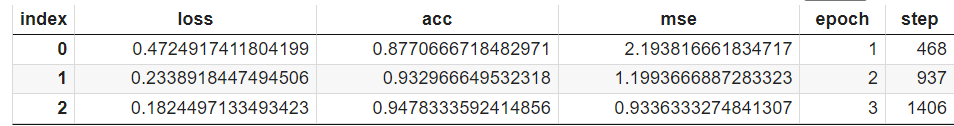

**trainer = L.Trainer(..., log_every_n_steps=10) # default:50**   

|index|loss\_step|acc\_step|mse\_step|epoch|step|loss\_epoch|acc\_epoch|mse\_epoch|
|---|---|---|---|---|---|---|---|---|
|0|1\.948105335235596|0\.5859375|4\.9453125|0|9|NaN|NaN|NaN|
|1|1\.6458293199539185|0\.6875|4\.7109375|0|19|NaN|NaN|NaN|
|2|1\.1539087295532229|0\.7890625|4\.7578125|0|29|NaN|NaN|NaN|
...
|140|0\.1302809417247772|0\.9609375|0\.921875|2|1389|NaN|NaN|NaN|
|141|0\.1583818793296814|0\.9375|0\.734375|2|1399|NaN|NaN|NaN|
|142|NaN|NaN|NaN|2|1406|0\.1823408305644989|0\.9470333456993104|0\.9592833518981934|

### validation_step( )

```python
## call triaining & validation process
trainer.fit(model, trainDataLoader, valDataLoader)
## call validation process
trainer.validate(model, valDataLoader)
```

```python
## basic code : step or epoch level
def validation_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self(x)
    loss = F.cross_entropy(y_hat, y)
    self.log("val_loss", loss)#, on_step=False, on_epoch=True)

## Display with PRogressBar
def validation_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self(x)
    loss = loss_function(y_hat, y)
    acc = FM.accuracy(y_hat, y)
    mse = FM.mean_squared_error(torch.argmax(y_hat, dim=1), y)
    metrics={'val_loss': loss, 'val_acc':acc, 'val_mse': mse}
    self.log_dict(metrics,prog_bar=True)#,on_step=False, on_epoch=True)
    return loss
```

In [ ]:
class MyModel(L.LightningModule):
    @classmethod
    def add_method(cls, fun):
      setattr(cls, fun.__name__, fun)
      return fun

    def __init__(self):
        super(MyModel, self).__init__()
        self.layers =  Model()

    def forward(self, x):
        out = self.layers(x)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        mse = FM.mean_squared_error(torch.softmax(y_pred, dim=1), F.one_hot(y,num_classes=10))
        metrics={'loss': loss, 'acc':acc, 'mse':mse}
        self.log_dict(metrics,prog_bar=True)#on_step=True, on_epoch=False)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = MyModel()
summary(model, input_size=(8, 1, 28, 28))

In [ ]:
@MyModel.add_method
def validation_step(self, batch, batch_idx):
    x, y = batch
    y_pred = self(x)
    loss = F.cross_entropy(y_pred, y)
    acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
    mse = FM.mean_squared_error(torch.softmax(y_pred, dim=1), F.one_hot(y,num_classes=10))
    metrics={'val_loss': loss, 'val_acc':acc, 'val_mse':mse}
    self.log_dict(metrics,prog_bar=True)#,on_step=False, on_epoch=True)

In [ ]:
%%time
epochs=3
logger = L.pytorch.loggers.CSVLogger("logs", name="val_history_log")
trainer = L.Trainer(max_epochs=epochs, logger=logger)
trainer.fit(model, trainDataLoader, valDataLoader)

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/val_history_log/version_{v_num}/metrics.csv')
history.groupby('epoch').last().drop('step', axis=1)
history

In [ ]:
trainer.validate(model,valDataLoader)

### test_step( )

```python
def test_step(self, batch, batch_idx):
    x, y = batch
    y_hat = self(x)
    loss = loss_function(y_hat, y)
    acc = FM.accuracy(y_hat, y)
    metrics={'test_loss': loss, 'test_acc':acc}
    #log를 남겨야 할 필요가 있다면 사용
    #self.log_dict(metrics)  #on_step=False, on_epoch=True
    return  {"test_loss": loss, "test_acc": acc}
```    

In [ ]:
## metrics 에서 mse 제거
@MyModel.add_method
def test_step(self, batch, batch_idx):
    x, y = batch
    y_pred = self(x)
    loss = F.cross_entropy(y_pred, y)
    acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
    metrics={'test_loss': loss, 'test_acc':acc}
    self.log_dict(metrics)

model = MyModel()

epochs=3
trainer = L.Trainer(max_epochs=epochs, accelerator='auto')
trainer.fit(model, trainDataLoader, valDataLoader)

In [ ]:
trainer.validate(model, valDataLoader)
trainer.test(model, valDataLoader)

### predict_step( )

**forward( )를 overide하여 학습된 모델을 실행하는 별도의 process를 생성 가능**

In [ ]:
@MyModel.add_method
def predict_step(self, x, batch_idx):
    y_pred = self(x)
    y_pb = F.softmax(y_pred,dim=1)     # nn.Softmax
    return y_pb

model = MyModel()
#summary(model, input_size=(8, 1, 28, 28))

epochs=3
trainer = L.Trainer(max_epochs=epochs, accelerator='auto')
trainer.fit(model, trainDataLoader, valDataLoader)

In [ ]:
batch = next(iter(valDataLoader)) # ((128,1,28,28),(128,10))
imgs = batch[0]                   # (128,1,28,28)

# forward()실행
y_logit = model(imgs)             ## (128,10)
ps(y_logit)
p(y_logit[0],'logit')             # 첫image에 대한 출력(logit)

# predict_step()실행
y_porb = trainer.predict(model, imgs)## list()
p(y_porb[0], 'prob.')             #  첫image에 대한 출력(prob.)

```python
class LitMCdropoutModel(L.LightningModule):
    def __init__(self, model, mc_iteration):
        super().__init__()
        self.model = model
        self.dropout = nn.Dropout()
        self.mc_iteration = mc_iteration

    def predict_step(self, batch, batch_idx):
        # enable Monte Carlo Dropout
        self.dropout.train() ## train flag
        # take average of `self.mc_iteration` iterations # torch.unsqueeze(0):(new_axis,...)
        pred = torch.vstack([self.dropout(self.model(x)).unsqueeze(0) for _ in range(self.mc_iteration)]).mean(dim=0)
        return pred
```

## Inference / Prediction   
### 예측 값은 torch.tensor특유의 attr.정보가 포함되어 있음  
### 추가로 제거 해야 함

In [ ]:
batch = next(iter(valDataLoader)) # ((128,1,28,28),(128,1))

##### Sets the module in evaluation mode.(Dropout,BN,..)
model.eval()

y_predict = model(batch[0])       # model(images)<-(images,labels)

p(y_predict,'(bs,10)')                 # (bs,10)
p(y_predict[0,:],'(10,)')            # (10,)
p(y_predict[0,:].detach(),'(10,)detached')   # (10,) w/o grad_fn
p(np.argmax(y_predict[0,:].detach()),'()scala tensor') # index tensor
p(np.argmax(y_predict[0,:].detach()).numpy(),'np') # index
#p(np.argmax(y_predict[0,:])) ## Error: Can't call numpy() on Tensor that requires grad.

<<(bs,10)>>:
Shape:torch.Size([128, 10])
Type: <class 'torch.Tensor'>
Values: tensor([[ -0.7671,  -7.7807,   0.0264,  ...,   8.7029,  -2.2554,   0.6003],
        [  1.9286,  -2.3078,   8.2968,  ...,  -9.3857,   0.4635, -11.2951],
        [ -3.9970,   5.5343,   0.1797,  ...,  -0.0248,  -0.1926,  -2.1313],
        ...,
        [ -5.7349,  -1.8784,   0.4251,  ...,  -1.0746,   0.3189,   4.9047],
        [  3.9101,  -7.8507,   1.5514,  ...,  -0.9109,  -1.4839,  -0.7175],
        [  0.1188,  -5.1952,  -2.7026,  ...,  -4.5404,   1.6500,  -2.6558]],
       grad_fn=<AddmmBackward0>)
<<(10,)>>:
Shape:torch.Size([10])
Type: <class 'torch.Tensor'>
Values: tensor([ -0.7671,  -7.7807,   0.0264,   2.1174,  -6.0105,  -1.5622, -10.0307,
          8.7029,  -2.2554,   0.6003], grad_fn=<SliceBackward0>)
<<(10,)detached>>:
Shape:torch.Size([10])
Type: <class 'torch.Tensor'>
Values: tensor([ -0.7671,  -7.7807,   0.0264,   2.1174,  -6.0105,  -1.5622, -10.0307,
          8.7029,  -2.2554,   0.6003])
<<()scala

**with torch.no_grad():**   
: gradient 계산을 위한 처리가 disable됨  
> grad_fn attribute 등이 없음   


---





In [ ]:
## disabled gradient calculation.(reduce memory)
with torch.no_grad():             ### w/o grad_fn object ###
    y_predict = model(batch[0])   # model(images)

p(y_predict,'\n')                 # (bs,10) tensor, w/o grad_fn
p(y_predict[0,:],'\n')            # (10,)    tensor, w/o grad_fn
p(np.argmax(y_predict[0,:].numpy()),'np') # numpy index
p(np.argmax(y_predict[0,:]),'tensor') # tensor index

Shape:torch.Size([128, 10])
Type: <class 'torch.Tensor'>
Values: tensor([[ -2.1871,  -7.5843,   1.3251,  ...,   7.8185,  -3.2604,  -1.0272],
        [ -2.9029,  -3.3035,   8.7376,  ..., -11.2591,   0.6438, -14.0168],
        [ -5.8018,   5.2731,   0.2959,  ...,  -0.1633,  -0.7122,  -3.8423],
        ...,
        [ -8.6152,  -1.9874,  -0.2734,  ...,  -1.9085,  -0.4571,   3.8130],
        [  3.4070,  -7.1172,   0.4709,  ...,  -2.6237,  -1.7350,  -0.3588],
        [ -2.5496,  -5.5480,  -5.5034,  ...,  -7.3882,   1.0956,  -3.4213]])

Shape:torch.Size([10])
Type: <class 'torch.Tensor'>
Values: tensor([ -2.1871,  -7.5843,   1.3251,   2.1897,  -7.8842,  -3.3131, -13.6494,
          7.8185,  -3.2604,  -1.0272])

<<np>>:
Shape:()
Type: <class 'numpy.int64'>
Values: 7
<<tensor>>:
Shape:torch.Size([])
Type: <class 'torch.Tensor'>
Values: 7


### nd.array와 torch.tensor의 표현 차이    
#### torch.tensor는 value == contents 임  

**values vs. contents**  
nd.array : value != contents

In [ ]:
l = [1,2,3,4]
print(l)      # [1, 2, 3, 4]

na = np.array(l)
print(na)     # [1 2 3 4] : value를 print
na            # array([1, 2, 3, 4]) : contents를 보여줌

[1, 2, 3, 4]
[1 2 3 4]


array([1, 2, 3, 4])

tensor : value == contents

In [ ]:
l = torch.tensor([1,2,3,4])
print(l)  # tensor([1, 2, 3, 4])
l         # tensor([1, 2, 3, 4])

tensor([1, 2, 3, 4])


tensor([1, 2, 3, 4])

In [ ]:
sum(pred == batch[1].numpy())/len(batch[1]) # accuracy

np.float64(0.9921875)